# 🌿 PlantVillage — Plant Disease Detection

## 📦 Section 1 — Environment Setup

Install all required libraries before running any other cell.

In [ ]:
!pip install streamlit tensorflow pillow numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 108.5 MB/s eta 0:00:00


In [ ]:
!pip install streamlit pyngrok tensorflow pillow numpy opencv-python

---
## 📥 Section 2 — Imports & Dataset Download

Import standard libraries and download the **PlantVillage** dataset via KaggleHub.

In [ ]:
import os
import glob as gb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import keras
import kagglehub
import streamlit as st
from PIL import Image
from pyngrok import ngrok
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Dense, GlobalAveragePooling2D, BatchNormalization, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

In [ ]:
# Download dataset

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded to: /kaggle/input/plantvillage-dataset


---
## 🔍 Section 3 — Data Loading & Preprocessing

### Steps
1. Locate the `color` subfolder inside the downloaded dataset
2. Walk every class folder and collect image paths
3. Label each image as **healthy** or **diseased**
4. **Balance** the dataset (equal samples per class)
5. Visualise sample images

In [ ]:
# Build the correct path to the "color" folder

color_path = os.path.join(path, "plantvillage dataset/color")
print("Color images path:", color_path)

Color images path: /kaggle/input/plantvillage-dataset/plantvillage dataset/color


In [ ]:
# Check if the folder exists

if not os.path.exists(color_path):
    raise FileNotFoundError(f"Color folder not found at {color_path}")

In [ ]:
# Now list the contents (optional, for verification)

print("Folders in color_path:", os.listdir(color_path))

Folders in color_path: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Potato___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Strawberry___Leaf_scorch', 'Peach___healthy', 'Apple___Apple_scab', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Apple___Black_rot', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Peach___Bacterial_spot', 'Apple___Cedar_apple_rust', 'Tomato___Target_Spot', 'Pepper,_bell___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Potato___Late_blight', 'Tomato___Tomato_mosaic_virus', 'Strawberry___healthy', 'Apple___healthy', 'Grape___Black_rot', 'Potato___Early_blight', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Common_rust_', 'Grape___Esca_(Black_Measles)', 'Raspberry___healthy', 'Tomato_

In [ ]:
# Collect healthy and diseased images

healthy_images = []
diseased_images = []

for folder in os.listdir(color_path):
    folder_path = os.path.join(color_path, folder)
    if os.path.isdir(folder_path):
        files = gb.glob(os.path.join(folder_path, '*.[jJ][pP][gG]'))
        if 'healthy' in folder.lower():
            healthy_images.extend(files)
        else:
            diseased_images.extend(files)

print(f"Total Healthy Images: {len(healthy_images)}")
print(f"Total Diseased Images: {len(diseased_images)}")

Total Healthy Images: 15083
Total Diseased Images: 39220


In [ ]:
# Create a dataframe with paths and labels

def get_label_from_path(img_path):
    folder_name = os.path.basename(os.path.dirname(img_path))
    return 'healthy' if 'healthy' in folder_name.lower() else 'diseased'

all_paths = healthy_images + diseased_images
all_labels = [get_label_from_path(p) for p in all_paths]

df = pd.DataFrame({'image_path': all_paths, 'label': all_labels})

In [ ]:
# Balance the dataset (same number healthy/diseased)

df_healthy = df[df['label'] == 'healthy']
df_diseased = df[df['label'] == 'diseased']

min_size = len(df_healthy)  # because healthy is usually the smaller class
df_diseased_balanced = df_diseased.sample(n=min_size, random_state=42)

df_balanced = pd.concat([df_healthy, df_diseased_balanced])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nBalanced dataset size:", len(df_balanced))
print(df_balanced['label'].value_counts())


Balanced dataset size: 30166
label
healthy     15083
diseased    15083
Name: count, dtype: int64


### 🖼️ Sample Image Visualisation

Display 8 random images (4 healthy + 4 diseased) to sanity-check the data.

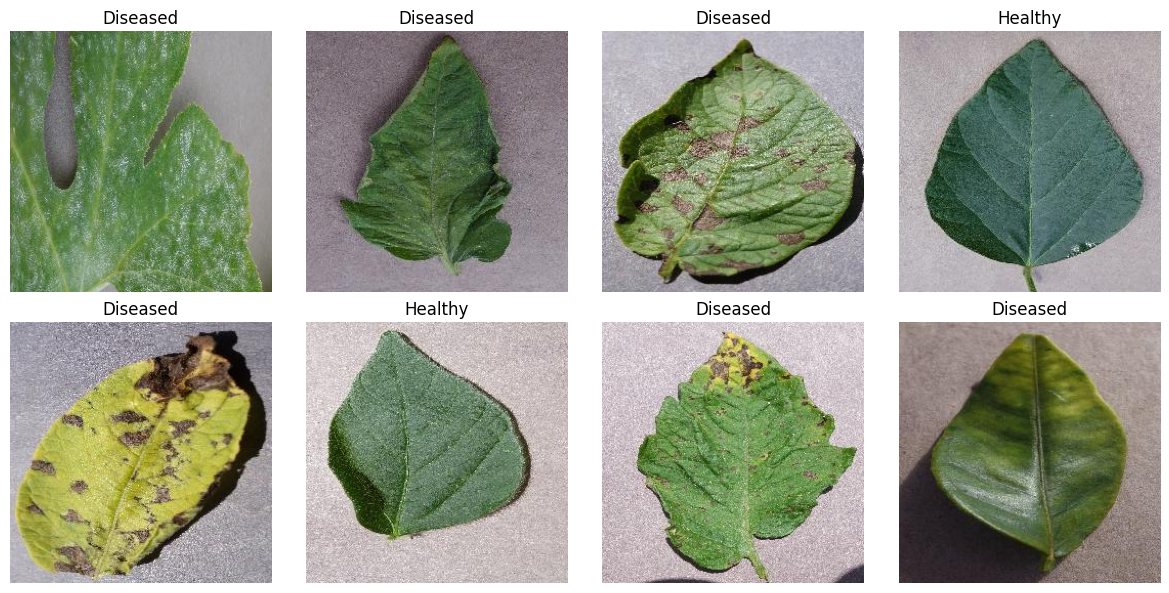

In [ ]:
# Show a few sample images (uses minimal memory)

def show_sample_images(df, num_samples=8):
    samples = df.sample(n=num_samples)
    plt.figure(figsize=(12, 6))
    for i, (idx, row) in enumerate(samples.iterrows()):
        plt.subplot(2, num_samples//2, i+1)
        img = cv2.imread(row['image_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img)
        label = "Healthy" if row['label'] == 'healthy' else "Diseased"
        plt.title(label)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_sample_images(df_balanced)

---
## ✂️ Section 4 — Data Splitting & ImageDataGenerators

Split the balanced DataFrame into three sets, then wrap each in a Keras `ImageDataGenerator` for memory-efficient batch loading.

| Split | Ratio | Purpose |
|-------|-------|---------|
| Train | 68 % | Model learning |
| Validation | 12 % | Hyperparameter tuning |
| Test | 20 % | Final evaluation |

> All images are rescaled to **[0, 1]** and resized to **128 × 128 px**.

In [ ]:
# Data splitting using ImageDataGenerator (NO out‑of‑memory)

# We will split the dataframe into train+test first, then use generators.
# Alternatively, we can let the generator do an 80/20 split via validation_split.
# Here we choose a manual split for clear control.

# Split into train (80%) and test (20%) using sklearn
train_df, test_df = train_test_split(
    df_balanced, test_size=0.2, random_state=42, stratify=df_balanced['label']
)

# Further split train_df into train (85% of train) and validation (15% of train)
train_df, val_df = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df['label']
)

print("\nData split sizes:")
print(f"Train: {len(train_df)}  Validation: {len(val_df)}  Test: {len(test_df)}")


Data split sizes:
Train: 20512  Validation: 3620  Test: 6034


In [ ]:
# Create ImageDataGenerators (rescale, target size, batch loading)

# Data augmentation – we keep it simple for now: just rescaling.
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Generators that yield batches of (image, label)
batch_size = 32

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 20512 validated image filenames belonging to 2 classes.
Found 3620 validated image filenames belonging to 2 classes.
Found 6034 validated image filenames belonging to 2 classes.


### ✅ Generator Verification

Fetch one batch and inspect its shape to confirm the pipeline is working.


Example batch shapes:
Images batch shape: (32, 128, 128, 3)
Labels batch shape: (32,)


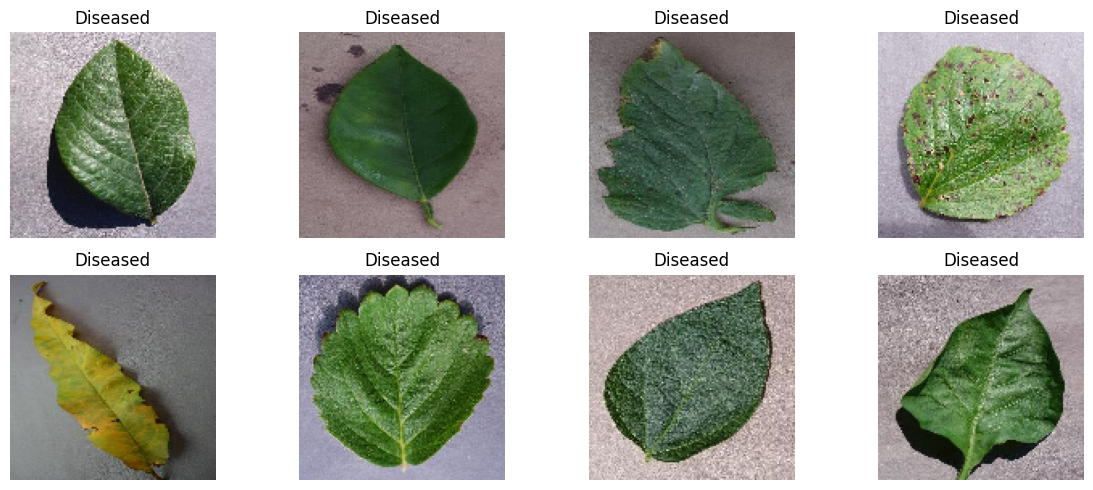

Data is ready for training! Use train_generator and val_generator in model.fit().
Example: model.fit(train_generator, validation_data=val_generator, epochs=10)


In [ ]:
# Quick verification of generator output

sample_images, sample_labels = next(train_generator)
print("\nExample batch shapes:")
print("Images batch shape:", sample_images.shape)   # (batch, 128, 128, 3)
print("Labels batch shape:", sample_labels.shape)   # (batch,)

# display one batch
plt.figure(figsize=(12, 5))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(sample_images[i])
    plt.title("Healthy" if sample_labels[i] == "healthy" else "Diseased")
    plt.axis('off')
plt.tight_layout()
plt.show()

print("Data is ready for training! Use train_generator and val_generator in model.fit().")
print("Example: model.fit(train_generator, validation_data=val_generator, epochs=10)")

---
## 🏗️ Section 5 — CNN Model Design

A custom **Convolutional Neural Network** with three conv-blocks:

```
Input (128×128×3)
  → Conv32 + BN → Conv32 → MaxPool → Dropout(0.25)
  → Conv64 + BN → Conv64 → MaxPool → Dropout(0.25)
  → Conv128 + BN         → MaxPool → Dropout(0.30)
  → GlobalAveragePooling2D
  → Dense(128, relu) → Dropout(0.5)
  → Dense(1, sigmoid)         ← binary output
```

**Optimizer:** Adam | **Loss:** Binary Cross-Entropy

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 63, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,961 (613.13 KB)

 Trainable params: 156,513 (611.38 KB)

 Non-trainable params: 448 (1.75 KB)

---
## 🏋️ Section 6 — CNN Training

Three callbacks are used to improve generalisation and avoid overfitting:

| Callback | Role |
|----------|------|
| `ModelCheckpoint` | Saves the best weights (val_accuracy) |
| `EarlyStopping` | Stops after 5 epochs with no improvement |
| `ReduceLROnPlateau` | Halves the learning rate on plateaus |

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

In [ ]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    class_mode="binary",
    batch_size=32,
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    class_mode="binary",
    batch_size=32,
    shuffle=False
)

Found 20512 validated image filenames belonging to 2 classes.
Found 3620 validated image filenames belonging to 2 classes.


In [ ]:
print(train_gen)
print(val_gen)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8577 - loss: 0.3233
Epoch 1: val_accuracy improved from None to 0.80635, saving model to /content/drive/MyDrive/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/best_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 139s 194ms/step - accuracy: 0.9012 - loss: 0.2400 - val_accuracy: 0.8064 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 2/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9527 - loss: 0.1213
Epoch 2: val_accuracy improved from 0.80635 to 0.96575, saving model to /content/drive/MyDrive/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/best_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 63ms/step - accuracy: 0.9581 - loss: 0.1107 - val_accuracy: 0.9657 - val_loss: 0.0893 - learning_rate: 0.0010
Epoch 3/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9666 - loss: 0.0912
Epoch 3: val_accuracy did not improve from 0.96575
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9680 - loss: 0.0869 - val_accuracy: 0.9478 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 4/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9731 - loss: 0.0764
Epoch 4: val_accuracy did not improve from 0.96575
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9729 - loss: 0.0779 - val_accuracy: 0.9448 - val_loss: 0.1466 - learning_rate: 0.0010
Epoch 5/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9781 - loss: 0.0608
Epoch 5: val_accuracy did not improve from 0.96575

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
641/641 


Epoch 6: finished saving model to /content/drive/MyDrive/best_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 40s 63ms/step - accuracy: 0.9850 - loss: 0.0418 - val_accuracy: 0.9823 - val_loss: 0.0481 - learning_rate: 5.0000e-04
Epoch 7/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9876 - loss: 0.0351
Epoch 7: val_accuracy did not improve from 0.98232
641/641 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9865 - loss: 0.0375 - val_accuracy: 0.8873 - val_loss: 0.2694 - learning_rate: 5.0000e-04
Epoch 8/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9902 - loss: 0.0310
Epoch 8: val_accuracy did not improve from 0.98232
641/641 ━━━━━━━━━━━━━━━━━━━━ 43s 67ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9602 - val_loss: 0.1520 - learning_rate: 5.0000e-04
Epoch 9/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9879 - loss: 0.0346
Epoch 9: val_accuracy did not improve from 0.98232

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.00025000001187436


Epoch 10: finished saving model to /content/drive/MyDrive/best_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.9914 - loss: 0.0238 - val_accuracy: 0.9884 - val_loss: 0.0380 - learning_rate: 2.5000e-04


### 💾 Model Checkpoint Verification

In [ ]:
if os.path.exists("/content/drive/MyDrive/best_model.h5"):
    print("✅ Model saved successfully to Drive!")
else:
    print("❌ There is a problem, the model is not found!")

✅ Model saved successfully to Drive!


---
## 📊 Section 7 — CNN Evaluation

Plot **Accuracy** and **Loss** curves for train vs validation, then evaluate on the held-out test set.

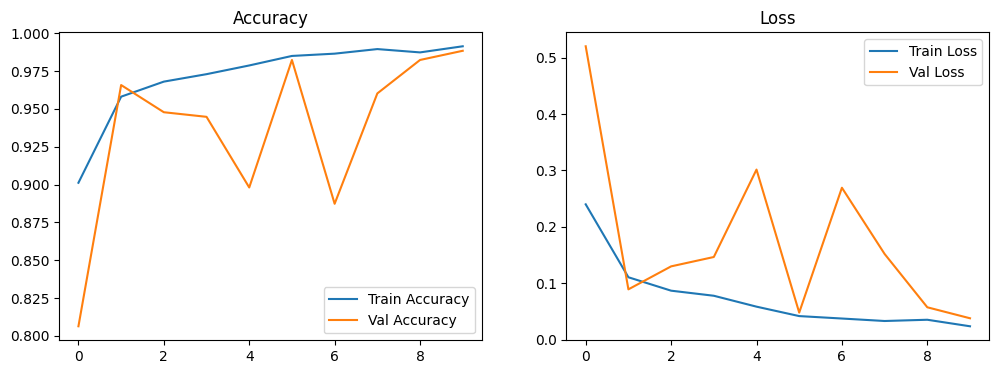

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="label",
    target_size=(128,128),
    class_mode="binary",
    batch_size=32,
    shuffle=False
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Found 6034 validated image filenames belonging to 2 classes.
189/189 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.9884 - loss: 0.0394
Test Accuracy: 98.84%
Test Loss: 0.0394


In [ ]:
import random

original_fit = tf.keras.Model.fit

best_score = 0
best_history = None

learning_rates = [0.001, 0.0005, 0.0001]
epochs_list = [5, 10]

print("Starting Evolution...")

for lr in learning_rates:
    for ep in epochs_list:

        print(f"\nTrial: lr={lr}, epochs={ep}")

        def custom_fit(self, *args, **kwargs):
            kwargs['epochs'] = ep

            if 'validation_data' not in kwargs and 'validation_split' not in kwargs:
                kwargs['validation_split'] = 0.2

            return original_fit(self, *args, **kwargs)

        tf.keras.Model.fit = custom_fit

        try:
            print("Run training cell now")

        except Exception as e:
            print("Error:", e)

print("\nDone")

Starting Evolution...

Trial: lr=0.001, epochs=5
Run training cell now

Trial: lr=0.001, epochs=10
Run training cell now

Trial: lr=0.0005, epochs=5
Run training cell now

Trial: lr=0.0005, epochs=10
Run training cell now

Trial: lr=0.0001, epochs=5
Run training cell now

Trial: lr=0.0001, epochs=10
Run training cell now

Done


---
## 🤖 Section 8 — ANN (Artificial Neural Network) Model

As a baseline comparison, a fully-connected ANN flattens each 128×128×3 image into a 49,152-dimensional vector and passes it through four dense layers.

```
Flatten → Dense(512) + BN + Dropout(0.4)
        → Dense(256) + BN + Dropout(0.4)
        → Dense(128) + BN + Dropout(0.3)
        → Dense(64)       + Dropout(0.3)
        → Dense(1, sigmoid)
```

> ⚠️ The ANN ignores spatial structure — CNN is expected to outperform it.

### 🔄 ANN Data Generators

Reuse the same rescaling generators already defined above.

In [ ]:
# Reuse the same datagens from your original notebook
# train_datagen, val_datagen, test_datagen already have rescale=1./255

BATCH_SIZE = 32
IMG_SIZE   = (128, 128)

ann_train_gen = train_datagen.flow_from_dataframe(
    dataframe   = train_df,
    x_col       = 'image_path',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = True
)

ann_val_gen = val_datagen.flow_from_dataframe(
    dataframe   = val_df,
    x_col       = 'image_path',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

ann_test_gen = test_datagen.flow_from_dataframe(
    dataframe   = test_df,
    x_col       = 'image_path',
    y_col       = 'label',
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'binary',
    shuffle     = False
)

print('Generators ready ✓')

Found 20512 validated image filenames belonging to 2 classes.
Found 3620 validated image filenames belonging to 2 classes.
Found 6034 validated image filenames belonging to 2 classes.
Generators ready ✓


### 🏗️ ANN Architecture

In [ ]:


ann_model = Sequential(name='ANN_PlantVillage')

# Flatten 128×128×3 image → 49152 vector (done inside model, per batch)
ann_model.add(Input(shape=(128, 128, 3)))
ann_model.add(Flatten())

# Hidden layer 1
ann_model.add(Dense(512, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.4))

# Hidden layer 2
ann_model.add(Dense(256, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.4))

# Hidden layer 3
ann_model.add(Dense(128, activation='relu'))
ann_model.add(BatchNormalization())
ann_model.add(Dropout(0.3))

# Hidden layer 4
ann_model.add(Dense(64, activation='relu'))
ann_model.add(Dropout(0.3))

# Output
ann_model.add(Dense(1, activation='sigmoid'))

ann_model.compile(
    optimizer = Adam(learning_rate=1e-3),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

ann_model.summary()

Model: "ANN_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,166,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,342,465 (96.67 MB)

 Trainable params: 25,340,673 (96.67 MB)

 Non-trainable params: 1,792 (7.00 KB)

### ⚙️ ANN Callbacks

In [ ]:

print('Callbacks ready ✓')

Callbacks ready ✓


In [ ]:

ann_callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_ann_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

### 🏋️ ANN Training

In [ ]:
ann_history = ann_model.fit(
    ann_train_gen,
    validation_data = ann_val_gen,
    epochs          = 10,
    callbacks       = ann_callbacks
)

Epoch 1/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7460 - loss: 0.5290
Epoch 1: val_accuracy improved from None to 0.72569, saving model to best_ann_model.h5



Epoch 1: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 51s 69ms/step - accuracy: 0.7810 - loss: 0.4639 - val_accuracy: 0.7257 - val_loss: 0.5978 - learning_rate: 0.0010
Epoch 2/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8159 - loss: 0.3918
Epoch 2: val_accuracy improved from 0.72569 to 0.74309, saving model to best_ann_model.h5



Epoch 2: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.8234 - loss: 0.3822 - val_accuracy: 0.7431 - val_loss: 0.5582 - learning_rate: 0.0010
Epoch 3/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8459 - loss: 0.3532
Epoch 3: val_accuracy improved from 0.74309 to 0.81906, saving model to best_ann_model.h5



Epoch 3: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - accuracy: 0.8397 - loss: 0.3623 - val_accuracy: 0.8191 - val_loss: 0.3848 - learning_rate: 0.0010
Epoch 4/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8408 - loss: 0.3472
Epoch 4: val_accuracy did not improve from 0.81906
641/641 ━━━━━━━━━━━━━━━━━━━━ 37s 57ms/step - accuracy: 0.8431 - loss: 0.3465 - val_accuracy: 0.6599 - val_loss: 0.8200 - learning_rate: 0.0010
Epoch 5/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8533 - loss: 0.3350
Epoch 5: val_accuracy did not improve from 0.81906
641/641 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.8485 - loss: 0.3431 - val_accuracy: 0.6655 - val_loss: 1.7113 - learning_rate: 0.0010
Epoch 6/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8459 - loss: 0.3398
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 6: val_accuracy did not improve from 0.81906
641/641 ━━━━━━━━━━━━━━━━━━━


Epoch 7: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 38s 60ms/step - accuracy: 0.8487 - loss: 0.3416 - val_accuracy: 0.8425 - val_loss: 0.5432 - learning_rate: 5.0000e-04
Epoch 8/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8522 - loss: 0.3342
Epoch 8: val_accuracy did not improve from 0.84254
641/641 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.8563 - loss: 0.3286 - val_accuracy: 0.8318 - val_loss: 0.5576 - learning_rate: 5.0000e-04
Epoch 9/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8711 - loss: 0.3002
Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 9: val_accuracy improved from 0.84254 to 0.85552, saving model to best_ann_model.h5



Epoch 9: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.8651 - loss: 0.3101 - val_accuracy: 0.8555 - val_loss: 0.5695 - learning_rate: 5.0000e-04
Epoch 10/10
640/641 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8711 - loss: 0.2973
Epoch 10: val_accuracy improved from 0.85552 to 0.86657, saving model to best_ann_model.h5



Epoch 10: finished saving model to best_ann_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 38s 59ms/step - accuracy: 0.8750 - loss: 0.2885 - val_accuracy: 0.8666 - val_loss: 0.5551 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 10.


### 📈 ANN Training Curves

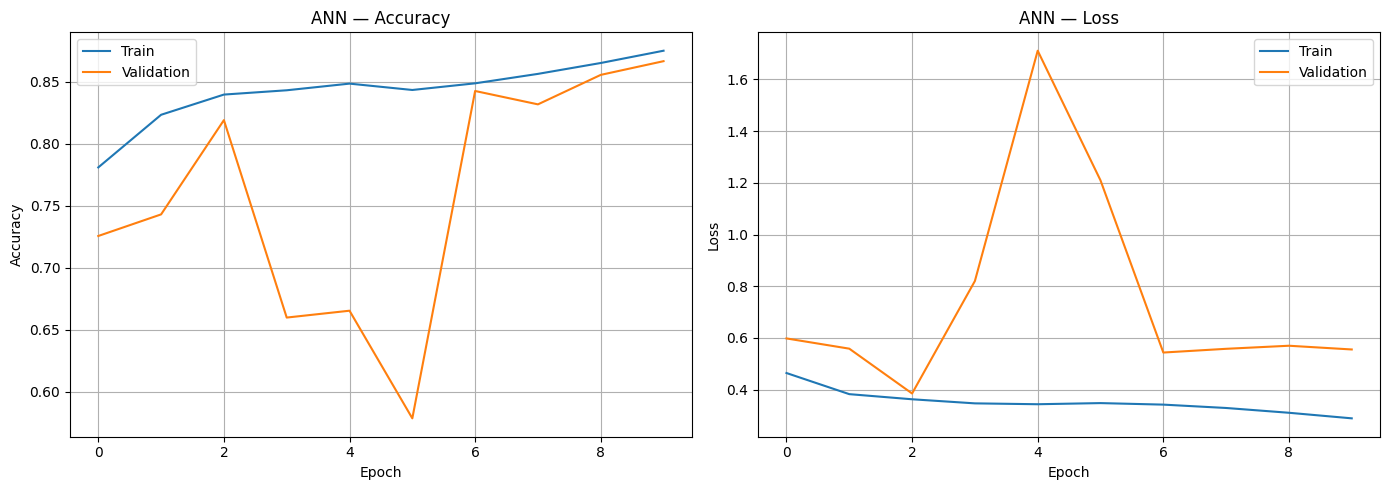

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(ann_history.history['accuracy'],     label='Train')
axes[0].plot(ann_history.history['val_accuracy'], label='Validation')
axes[0].set_title('ANN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(ann_history.history['loss'],     label='Train')
axes[1].plot(ann_history.history['val_loss'], label='Validation')
axes[1].set_title('ANN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 📊 ANN Evaluation on Test Set

Compute Loss, Accuracy, Classification Report and Confusion Matrix.

Test Loss     : 0.2863
Test Accuracy : 0.8709
189/189 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step

Classification Report:
              precision    recall  f1-score   support

    diseased       0.88      0.86      0.87      3017
     healthy       0.86      0.88      0.87      3017

    accuracy                           0.87      6034
   macro avg       0.87      0.87      0.87      6034
weighted avg       0.87      0.87      0.87      6034



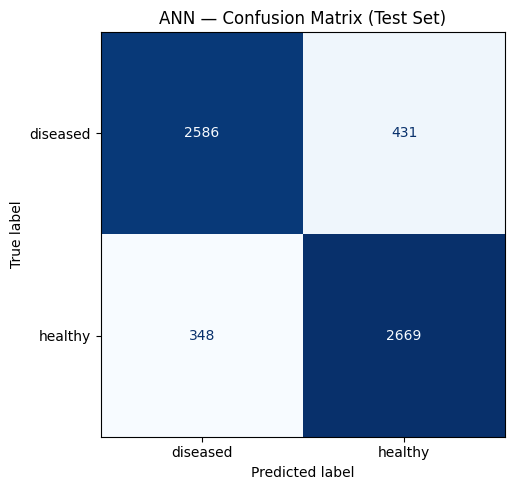

In [ ]:
# Loss & Accuracy
test_loss, test_acc = ann_model.evaluate(ann_test_gen, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

# Predictions
ann_test_gen.reset()
y_pred_prob = ann_model.predict(ann_test_gen).ravel()
y_pred      = (y_pred_prob >= 0.5).astype(int)
y_true      = ann_test_gen.classes

class_names = list(ann_test_gen.class_indices.keys())

print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm   = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('ANN — Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

### 🏆 CNN vs ANN Comparison

Side-by-side accuracy and loss on the same test set.

In [ ]:
try:
    cnn_loss, cnn_acc = model.evaluate(test_generator, verbose=0)
    print('\n=== Model Comparison on Test Set ===')
    print(f'{"Model":<10} {"Loss":>8} {"Accuracy":>10}')
    print('-' * 32)
    print(f'{"CNN":<10} {cnn_loss:>8.4f} {cnn_acc:>10.4f}')
    print(f'{"ANN":<10} {test_loss:>8.4f} {test_acc:>10.4f}')
except NameError:
    print('CNN model not found in scope — skipping comparison.')


=== Model Comparison on Test Set ===
Model          Loss   Accuracy
--------------------------------
CNN          0.0394     0.9884
ANN          0.2863     0.8709


---
## 🚀 Section 9 — Save Model & Streamlit Deployment

Save the trained CNN to disk, then launch a **Streamlit** web app that accepts a leaf image upload and returns a Healthy / Diseased prediction.

In [ ]:
model.save("model.keras")

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import cv2
from tensorflow.keras.models import load_model
from PIL import Image

# Load the model
model = load_model("model.keras")

st.title("🌿 Plant Disease Detection")
st.write("Upload a leaf image")

uploaded_file = st.file_uploader("Choose an image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:

    # Read the image
    file_bytes = np.asarray(bytearray(uploaded_file.read()), dtype=np.uint8)
    img_bgr = cv2.imdecode(file_bytes, 1)

    if img_bgr is None:
        st.error("Error loading image")
    else:

        # BGR → RGB
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Display the image
        st.image(img_rgb, caption="Uploaded Image", use_container_width=True)

        # Preprocessing
        img_resized = cv2.resize(img_rgb, (128, 128))
        img_normalized = img_resized / 255.0
        img_final = np.expand_dims(img_normalized, axis=0)

        # Prediction
        prediction = model.predict(img_final, verbose=0)
        prob = prediction[0][0]

        # Same logic as before
        if prob <= 0.5:
            label = "Diseased"
            confidence = prob

            st.error(f"Prediction: {label} 😷🌱")
            st.write(f"Confidence: {confidence:.2f}")

        else:
            label = "Healthy"
            confidence = 1 - prob

            st.success(f"Prediction: {label} 🌱")
            st.write(f"Confidence: {confidence:.2f}")

Writing app.py


In [ ]:
!streamlit run app.py &>/dev/null &

In [ ]:
!ngrok authtoken 3DLVEo9xybMRbl38rG0ry9h3wA4_3k7mCaXKLxVPkES6oeCNW

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://crayon-numeral-catacomb.ngrok-free.dev" -> "http://localhost:8501"


---
## 🔬 Section 10 — ResNet50 Transfer Learning

Fine-tune a **ResNet50** backbone (pre-trained on ImageNet) for our binary classification task.

| Stage | Layers frozen | Purpose |
|-------|--------------|---------|
| Feature extraction | All ResNet layers | Learn domain-specific head |
| Fine-tuning | Top layers unfrozen | Adapt deeper features |

> Input images must be preprocessed with `tensorflow.keras.applications.resnet50.preprocess_input`.

In [ ]:

img_size = (128, 128)


base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))


for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
predictions = tf.keras.layers.Dense(1, activation='sigmoid')(x)

# Assemble the complete model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

# 4. Compile the model
resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# 1. Create a ResNet-specific Generator that uses its preprocessing function
# Removed rescale=1./255 and added preprocessing_function
resnet_train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
resnet_val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# 2. Create the Generators
resnet_train_gen = resnet_train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

resnet_val_gen = resnet_val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 20512 validated image filenames belonging to 2 classes.
Found 3620 validated image filenames belonging to 2 classes.


### ⚙️ ResNet50 Callbacks & Training

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Change the file name here so it doesn't overwrite old models
resnet_checkpoint = ModelCheckpoint(
    'best_resnet50_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

# You can reuse the rest of the callbacks as usual
resnet_callbacks = [
    resnet_checkpoint,
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

# And start training with the new callbacks
history_resnet = resnet_model.fit(
    resnet_train_gen,
    validation_data=resnet_val_gen,
    epochs=10,
    callbacks=resnet_callbacks
)

Epoch 1/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9175 - loss: 0.2125
Epoch 1: val_accuracy improved from None to 0.97459, saving model to best_resnet50_model.h5



Epoch 1: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 69s 88ms/step - accuracy: 0.9482 - loss: 0.1332 - val_accuracy: 0.9746 - val_loss: 0.0697 - learning_rate: 0.0010
Epoch 2/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9728 - loss: 0.0766
Epoch 2: val_accuracy improved from 0.97459 to 0.98039, saving model to best_resnet50_model.h5



Epoch 2: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 49s 77ms/step - accuracy: 0.9743 - loss: 0.0708 - val_accuracy: 0.9804 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 3/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9740 - loss: 0.0692
Epoch 3: val_accuracy improved from 0.98039 to 0.98066, saving model to best_resnet50_model.h5



Epoch 3: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.9765 - loss: 0.0631 - val_accuracy: 0.9807 - val_loss: 0.0526 - learning_rate: 0.0010
Epoch 4/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9800 - loss: 0.0514
Epoch 4: val_accuracy improved from 0.98066 to 0.98343, saving model to best_resnet50_model.h5



Epoch 4: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 51s 80ms/step - accuracy: 0.9800 - loss: 0.0552 - val_accuracy: 0.9834 - val_loss: 0.0482 - learning_rate: 0.0010
Epoch 5/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9828 - loss: 0.0437
Epoch 5: val_accuracy improved from 0.98343 to 0.98453, saving model to best_resnet50_model.h5



Epoch 5: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 48s 75ms/step - accuracy: 0.9846 - loss: 0.0404 - val_accuracy: 0.9845 - val_loss: 0.0481 - learning_rate: 0.0010
Epoch 6/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9849 - loss: 0.0423
Epoch 6: val_accuracy improved from 0.98453 to 0.98785, saving model to best_resnet50_model.h5



Epoch 6: finished saving model to best_resnet50_model.h5
641/641 ━━━━━━━━━━━━━━━━━━━━ 48s 74ms/step - accuracy: 0.9844 - loss: 0.0439 - val_accuracy: 0.9878 - val_loss: 0.0379 - learning_rate: 0.0010
Epoch 7/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9878 - loss: 0.0342
Epoch 7: val_accuracy did not improve from 0.98785
641/641 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step - accuracy: 0.9864 - loss: 0.0358 - val_accuracy: 0.9843 - val_loss: 0.0421 - learning_rate: 0.0010
Epoch 8/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9885 - loss: 0.0311
Epoch 8: val_accuracy did not improve from 0.98785
641/641 ━━━━━━━━━━━━━━━━━━━━ 53s 83ms/step - accuracy: 0.9876 - loss: 0.0334 - val_accuracy: 0.9873 - val_loss: 0.0389 - learning_rate: 0.0010
Epoch 9/10
641/641 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9891 - loss: 0.0300
Epoch 9: val_accuracy did not improve from 0.98785
641/641 ━━━━━━━━━━━━━━━━━━━━ 47s 73ms/step - accuracy: 0.9885 - loss: 0.0315 - val_accuracy: 0.9865

In [ ]:
resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
resnet_test_gen = resnet_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='label',
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


resnet_loss, resnet_acc = resnet_model.evaluate(resnet_test_gen)

Found 6034 validated image filenames belonging to 2 classes.
189/189 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.9897 - loss: 0.0268


### 🏆 Full Model Comparison

CNN vs ANN vs ResNet50 — accuracy and loss on the held-out test set.

In [ ]:
try:
    # Evaluate other models
    cnn_loss, cnn_acc = model.evaluate(test_generator, verbose=0)
    ann_loss, ann_acc = ann_model.evaluate(ann_test_gen, verbose=0)
    # Evaluate ResNet which we just calculated
    resnet_loss, resnet_acc = resnet_model.evaluate(resnet_test_gen, verbose=0)

    print('\n' + '='*45)
    print(f"{'Model Type':<20} | {'Loss':<10} | {'Accuracy':<10}")
    print('-'*45)
    print(f"{'CNN Custom':<20} | {cnn_loss:<10.4f} | {cnn_acc:<10.4f}")
    print(f"{'ANN Basic':<20} | {ann_loss:<10.4f} | {ann_acc:<10.4f}")
    print(f"{'ResNet50 (TL)':<20} | {resnet_loss:<10.4f} | {resnet_acc:<10.4f}")
    print('='*45)
except Exception as e:
    print("Make sure to run all previous model cells for comparison.")


Model Type           | Loss       | Accuracy  
---------------------------------------------
CNN Custom           | 0.0394     | 0.9884    
ANN Basic            | 0.2863     | 0.8709    
ResNet50 (TL)        | 0.0268     | 0.9897    


### 📈 ResNet50 Training Curves

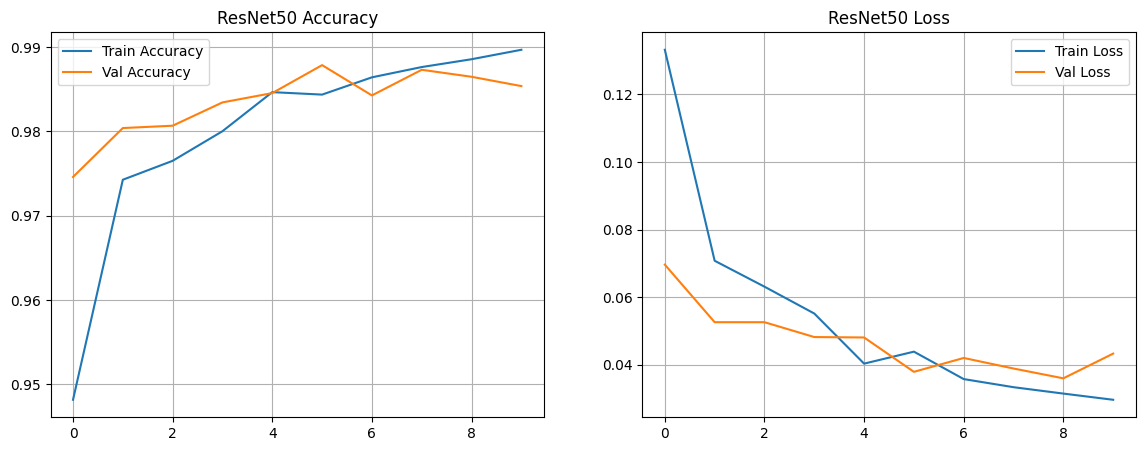

In [ ]:
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Val Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['loss'], label='Train Loss')
plt.plot(history_resnet.history['val_loss'], label='Val Loss')
plt.title('ResNet50 Loss')
plt.legend()
plt.grid(True)

plt.show()

---
## ✅ Summary

| Model | Architecture | Highlights |
|-------|-------------|------------|
| **CNN** | 3 Conv blocks + GAP | Best accuracy, spatial features |
| **ANN** | 4 Dense layers | Baseline, no spatial awareness |
| **ResNet50** | Transfer learning | ImageNet features, fast convergence |

**Dataset:** PlantVillage — binary (healthy vs diseased)  
**Image size:** 128 × 128 px  
**Deployment:** Streamlit + ngrok (Google Colab)